In [1]:
from google.colab import drive
import zipfile
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
dataset_path ="/content/drive/MyDrive/cassava_leaves.zip"


In [4]:
# Extract the dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall('/content/cassava_leave_dataset')

In [8]:
# Set extracted dataset directory
data_dir = "/content/cassava_leave_dataset"

In [9]:
# Check if dataset is extracted successfully
print("Files in dataset folder:", os.listdir(data_dir))

Files in dataset folder: ['cassava_leaves']


In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image size and batch size
img_size = (150, 150)
batch_size = 32

# Create an ImageDataGenerator for preprocessing and splitting
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values
    validation_split=0.2  # Split 20% of data for validation
)

# Load training data
train_generator = datagen.flow_from_directory(
    '/content/cassava_leave_dataset/cassava_leaves',  # Point to the parent folder
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',  # Use one-hot encoded labels
    subset='training'  # Use 80% of the data for training
)

# Load validation data
validation_generator = datagen.flow_from_directory(
    '/content/cassava_leave_dataset/cassava_leaves',  # Point to the parent folder
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',  # Use one-hot encoded labels
    subset='validation'  # Use 20% of the data for validation
)

Found 4000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


In [32]:
# Check class names
class_names = list(train_generator.class_indices.keys())
print("Class names:", class_names)

# Check the shape of the labels
for images, labels in train_generator:
    print("Batch of images shape:", images.shape)
    print("Batch of labels shape:", labels.shape)
    break

Class names: ['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']
Batch of images shape: (32, 150, 150, 3)
Batch of labels shape: (32, 5)


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Build the model
model = Sequential([
    Flatten(input_shape=(150, 150, 3)),  # Flatten the input image
    Dense(128, activation='relu'),  # Fully connected layer with 128 units
    Dense(64, activation='relu'),  # Fully connected layer with 64 units
    Dense(5, activation='softmax')  # Output layer with 5 units (one for each class)
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Use categorical crossentropy for one-hot encoded labels
              metrics=['accuracy'])

# Print model summary
model.summary()

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=10
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)                  │ (None, 67500)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 128)                 │       8,640,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,648,709 (32.99 MB)

 Trainable params: 8,648,709 (32.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 347ms/step - accuracy: 0.1921 - loss: 10.0464 - val_accuracy: 0.1895 - val_loss: 2.6777
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 346ms/step - accuracy: 0.2712 - loss: 2.4014 - val_accuracy: 0.3155 - val_loss: 1.6307
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 83s 352ms/step - accuracy: 0.3322 - loss: 1.7139 - val_accuracy: 0.2974 - val_loss: 1.6851
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 348ms/step - accuracy: 0.3760 - loss: 1.5663 - val_accuracy: 0.2954 - val_loss: 1.7769
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 85s 369ms/step - accuracy: 0.4408 - loss: 1.4057 - val_accuracy: 0.2611 - val_loss: 2.6649
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 349ms/step - accuracy: 0.4096 - loss: 1.4813 - val_accuracy: 0.2127 - val_loss: 2.3420
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 84s 368ms/step - accuracy: 0.5249 - loss: 1.2320 - val_accuracy: 0.2702 - val_loss: 1.7041
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 348ms/step - accuracy: 0.5463 - loss: 

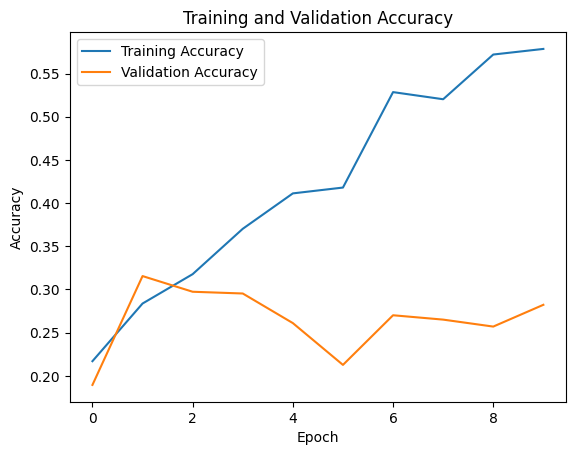

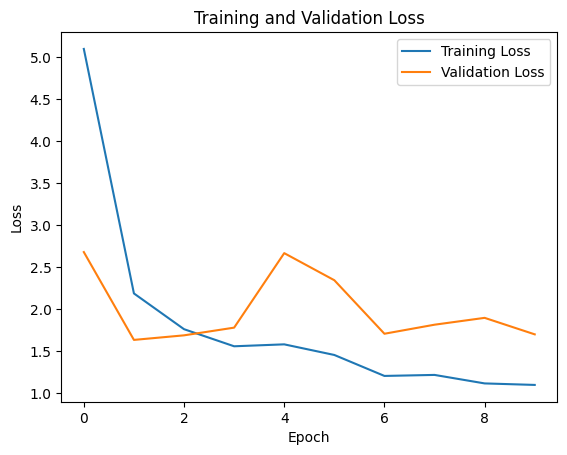

In [35]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [36]:
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.2834 - loss: 1.7144
Validation Loss: 1.698480486869812
Validation Accuracy: 0.28200000524520874


In [38]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load and preprocess a new image
img_path = '/content/cassava_leave_dataset/cassava_leaves/Cassava___healthy/1001723730.jpg'
img = image.load_img(img_path, target_size=img_size)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array /= 255.0  # Normalize pixel values

# Make a prediction
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions, axis=1)

# Map the predicted class index to the class name
predicted_class_name = class_names[predicted_class[0]]
print("Predicted class:", predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted class: Cassava___bacterial_blight


In [39]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(validation_generator)

# Print the validation accuracy
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

# Evaluate the model on the training set
train_loss, train_accuracy = model.evaluate(train_generator)
print(f"Training Loss: {train_loss}")
print(f"Training Accuracy: {train_accuracy}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.2934 - loss: 1.6691
Validation Loss: 1.698480486869812
Validation Accuracy: 0.28200000524520874
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.7275 - loss: 0.8287
Training Loss: 0.8316922783851624
Training Accuracy: 0.7192500233650208


In [40]:
from google.colab import drive
drive.flush_and_unmount()
